# 🧠 Modelo 2: Red Neuronal Convolucional (CNN)

Este notebook entrena una CNN básica para la clasificación de imágenes OCT. El modelo se carga desde el archivo `modelos/modelo_cnn.py`.

---

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub
from sklearn.metrics import classification_report, confusion_matrix

# Añadir el directorio raíz al path para importar módulos locales
sys.path.append('..')
import oct_dataloader as dataloaders
import modelos.modelo_cnn as cnn_model

print("✅ Librerías importadas")

c:\Users\pablo\miniconda3\envs\oct_gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Librerías importadas


In [2]:
# Configurar GPUs si están disponibles
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    
print(gpus)

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Descargar y preparar dataset en carpeta local (Disco D)
path = kagglehub.dataset_download("anirudhcv/labeled-optical-coherence-tomography-oct")

data_path = path
for root, dirs, files in os.walk(path):
    if 'train' in dirs and 'test' in dirs:
        data_path = root
        break

print(f"✅ Dataset en: {data_path}")

# Hiperparámetros de carga
IMG_SIZE = (128, 128) # Mayor resolución para CNN
BATCH_SIZE = 64

train_ds, val_ds, test_ds, class_names = dataloaders.create_oct_dataloaders(
    data_path=data_path,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    train_subset_fraction=0.8, 
    optimize=False
)

✅ Dataset en: C:\Users\pablo\.cache\kagglehub\datasets\anirudhcv\labeled-optical-coherence-tomography-oct\versions\2\Dataset - train+val+test
⚙️ Configuración de DataLoaders
   • Tamaño de imagen: (128, 128)
   • Batch size: 64
   • Clases: ['CNV', 'DME', 'DRUSEN', 'NORMAL']
   • Train subset: 80.0%
   • Seed: 42

📦 Creando data loader de entrenamiento...
Found 76515 files belonging to 4 classes.
   ⚠️  Usando 80.0% del dataset de entrenamiento
   ⚠️  Batches: 956 de 1196
✅ Data loader de entrenamiento creado

📦 Creando data loader de validación...
Found 21861 files belonging to 4 classes.
✅ Data loader de validación creado

📦 Creando data loader de prueba...
Found 10933 files belonging to 4 classes.
✅ Data loader de prueba creado

📊 RESUMEN DE DATASETS
Train:      956 batches
Validation: 342 batches
Test:       171 batches



In [4]:
# Crear y compilar el modelo
model = cnn_model.create_cnn(input_shape=(128, 128, 1), num_classes=4)
model = cnn_model.compile_model(model, learning_rate=0.000001)
cnn_model.print_model_summary(model)

Model: "BasicCNN"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 64, 64, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 64, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 32, 32, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 32, 32, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 16, 16, 128)      0  

In [5]:
# Entrenamiento
EPOCHS = 100
callbacks = [tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/100
956/956 [==============================] - 40s 38ms/step - loss: 2.3432 - accuracy: 0.4159 - val_loss: 1.1546 - val_accuracy: 0.5178
Epoch 2/100
956/956 [==============================] - 36s 38ms/step - loss: 1.2145 - accuracy: 0.4892 - val_loss: 1.1085 - val_accuracy: 0.5444
Epoch 3/100
956/956 [==============================] - 36s 38ms/step - loss: 1.1740 - accuracy: 0.5132 - val_loss: 1.0804 - val_accuracy: 0.5675
Epoch 4/100
956/956 [==============================] - 36s 38ms/step - loss: 1.1467 - accuracy: 0.5312 - val_loss: 1.0547 - val_accuracy: 0.5890
Epoch 5/100
956/956 [==============================] - 36s 38ms/step - loss: 1.1221 - accuracy: 0.5452 - val_loss: 1.0249 - val_accuracy: 0.6100
Epoch 6/100
956/956 [==============================] - 36s 38ms/step - loss: 1.0942 - accuracy: 0.5610 - val_loss: 0.9930 - val_accuracy: 0.6256
Epoch 7/100
956/956 [==============================] - 37s 38ms/step - loss: 1.0661 - accuracy: 0.5819 - val_loss: 0.9685 - val_ac

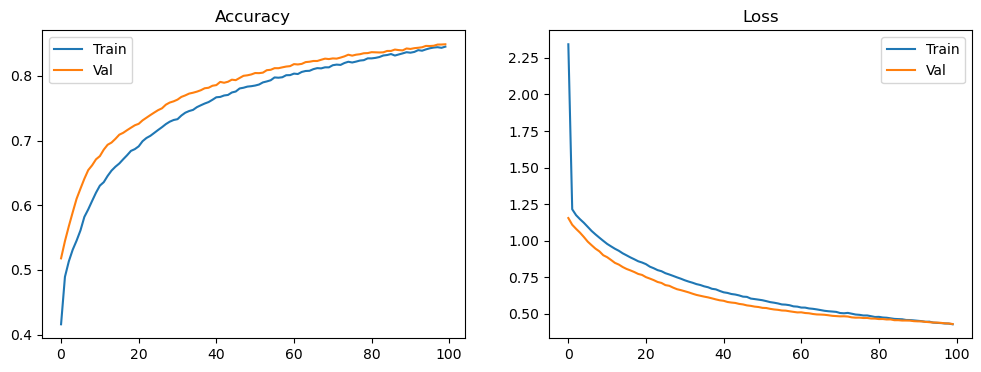

In [6]:
# Curvas de aprendizaje
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()
plt.show()

In [ ]:
# Evaluación final
loss_train, acc_train = model.evaluate(train_ds, verbose=0)
loss_val, acc_val = model.evaluate(val_ds, verbose=0)
loss_test, acc_test = model.evaluate(test_ds, verbose=0)

print(f"Resultados: Train={acc_train:.4f}, Val={acc_val:.4f}, Test={acc_test:.4f}")
print(f"Parámetros del modelo: {model.count_params():,}")

Resultados: Train=0.8791, Val=0.8489, Test=0.8468
Parámetros del modelo: 4,287,620


: 